In [1]:
#from google.colab import drive
#drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import numpy.lib.recfunctions as rfn
from   numpy.polynomial.legendre import legval

import plotly.graph_objects as go
from ipywidgets import interact, IntSlider

from scipy.special import eval_legendre,legendre,factorial
from scipy.optimize import curve_fit, least_squares, differential_evolution

# Import des données

In [2]:
# Tableau : Ar-HCN
Ar = np.genfromtxt("Data/Ar-HCN.txt",
                   delimiter=",", names=True, dtype=None, encoding="utf-8")

# Conversion des µEh en mEh
energy_mEh = Ar['Energy'] * 1e-3
# Ajout de la colonne en Eh
Ar = rfn.append_fields(Ar, names='Energy_mEh', data=energy_mEh, usemask=False)

# Parametres donnés par Toczylowski
params_Ar = np.array([ 1.48547,   0.05926,  -0.07533,   0.12892,   0.04978,-0.00004, # b
                      -134348.77,-281277.47,-57041.638,-116961.41,                   # c
                       14.23209,  0.99248,  0.88287,    0.70551,   0.38213, 0.06818, # d
                       0.06053,  -0.12937,  0.07849,   -0.05992,   0.04541, 0.03519, # g0
                       0.00640,   0.04016, -0.02325,    0.02468,  -0.02338,-0.01536, # g1
                      -0.00277,  -0.00416,  0.00221,   -0.00239,   0.00392, 0.00207, # g2
                       0.00013,   0.00015, -0.00006,    0.00003,  -0.00021,-0.00009])# g3

# Implémentation des fonctions

In [3]:
def f6_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x / 720.0)))))
  return 1.0 - np.exp(-x) * y

def f7_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x * (1.0/720.0 + x / 5040.0))))))
  return 1.0 - np.exp(-x) * y

In [24]:
def V_opt(p, R, Theta):
  R = np.asarray(R, dtype=float)
  # On calcule ces valeurs car utiles plusieurs fois
  cosTh = np.cos(np.deg2rad(np.asarray(Theta, dtype=float)))

  # Paramètres
  b  = p[0:6]                            # b0, b1, b2, b3, b4, b5
  c  = p[6:10]                           # c0, c1, c2, c3
  d  = p[10:16]                          # d0, d1, d2, d3, d4, d5
  g0 = np.asarray(p[16:22], dtype=float) # g00, g01, g02, g03, g04, g05
  g1 = np.asarray(p[22:28], dtype=float) # g10, g11, g12, g13, g14, g15
  g2 = np.asarray(p[28:34], dtype=float) # g20, g21, g22, g23, g24, g25
  g3 = np.asarray(p[34:40], dtype=float) # g30, g31, g32, g33, g34, g35

  # X(theta) ------------------------------------ #
  # --------------------------------------------- #
  X_b = legval(cosTh, b)
  X_d = legval(cosTh, d)

  X_bR = X_b * R
  abs_BR = np.abs(X_bR)
  # --------------------------------------------- #

  # G(R,theta) ---------------------------------- #
  # --------------------------------------------- #
  i = np.arange(6)
  g = g0[i, None] + R * (g1[i, None] + R * (g2[i, None] + R * g3[i, None]))
  Pl = np.array([eval_legendre(l, cosTh) for l in range(6)])
  # G = np.sum(g * Pl, axis=0)
  # ------------------------------------------- #

  # Short-Range
  exp_val = np.clip(X_d-X_bR,-200,200) # Bloquage des valeurs trop grandes/petites
  V_sh = np.sum(g * Pl, axis=0) * np.exp(exp_val)

  # Asymptotic
  inv_R = 1.0/R
  inv_R6 = inv_R * inv_R * inv_R * inv_R * inv_R * inv_R
  inv_R7 = inv_R6 * inv_R

  V_as = (f6_opt(abs_BR) * legval(cosTh,[c[0],0,c[2]]) * inv_R6
        + f7_opt(abs_BR) * legval(cosTh,[0,c[1],0,c[3]]) * inv_R7)

  V_total = V_sh + V_as

  # Pour ne pas renvoyer NaN en cas d'erreur
  V_total = np.nan_to_num(V_total, nan=1e100, posinf=1e100, neginf=-1e100)
  # Bloquage des valeurs trop grandes
  V_total = np.clip(V_total, -1e100, 1e100)
  
  return V_total # Energie renvoyée en mEh

# Fonctions de métriques

In [5]:
def rsq(y, f):
  y = np.asarray(y)
  f = np.asarray(f)
  stot = np.sum((y-np.mean(y))**2)
  sres = np.sum((y-f)**2)
  return 1.0 - sres/stot


# y == valeurs tabulées

# f == f(x, y, popt)

In [19]:
def rmse(y, f):
    y = np.asarray(y)
    f = np.asarray(f)
    return np.sqrt(np.mean((y-f)**2))

In [20]:
def mae(y,f):
    y = np.asarray(y)
    f = np.asarray(f)
    return np.mean(np.abs(y-f))

# Fonction d'affichage

In [6]:
def plot_interactif(
    model,
    params,
    fixed_vals,
    x,
    data,
    fixed_col,
    x_col,
    y_col,
    title="Graphique interactif",
    fixed_first=True
):

    fig = go.Figure()

    for i, val in enumerate(fixed_vals):

        # ordre des variables
        if fixed_first:
            y_model = model(params, np.full_like(x, val), x)
        else:
            y_model = model(params, x, np.full_like(x, val))

        # données
        mask = np.isclose(data[fixed_col], val)

        x_data = data[x_col][mask]
        y_data = data[y_col][mask]

        order = np.argsort(x_data)

        visible = (i == 0)

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y_model,
                mode='lines',
                name='Modèle',
                visible=visible
            )
        )

        fig.add_trace(
            go.Scatter(
                x=x_data[order],
                y=y_data[order],
                mode='markers',
                name='Données',
                visible=visible
            )
        )

    steps = []

    for i, val in enumerate(fixed_vals):

        vis = [False] * (2 * len(fixed_vals))

        vis[2*i] = True
        vis[2*i+1] = True

        steps.append(
            dict(
                method="update",
                args=[
                    {"visible": vis},
                    {"title": f"{fixed_col} = {val}"}
                ],
                label=str(val)
            )
        )

    fig.update_layout(
        title=title,
        sliders=[dict(steps=steps)],
        template="plotly_white",
        width=600,
        height=400,
        uirevision=True
    )

    fig.show()

# Méthode 1 : curve_fit

In [7]:
def V_curvefit(vars, *p):
    R, Theta = vars
    return V_opt(p, R, Theta)

## Calculs

In [8]:
R = np.asarray(Ar["R"], dtype=float)
Theta = np.asarray(Ar["Theta"], dtype=float)
V_table = np.asarray(Ar["Energy_mEh"], dtype=float)
R.shape, Theta.shape, V_table.shape

((140,), (140,), (140,))

In [29]:
#params_init_cf = 10 * np.random.rand(40) - 5
#print(params_init_cf)
params_opt_cf, params_cov = curve_fit(V_curvefit, (R, Theta), V_table,
                                      p0=params_Ar, maxfev=1000000,
                                      method="lm")
params_opt_cf_sigma, params_cov = curve_fit(V_curvefit, (R, Theta), V_table,
                                      p0=params_Ar, maxfev=1000000,
                                      method="lm", sigma=V_table)

In [26]:
b  = params_opt_cf[0:6]   # b0, b1, b2, b3, b4, b5
c  = params_opt_cf[6:10]  # c0, c1, c2, c3
d  = params_opt_cf[10:16] # d0, d1, d2, d3, d4, d5
g0 = params_opt_cf[16:22] # g00, g01, g02, g03, g04, g05
g1 = params_opt_cf[22:28] # g10, g11, g12, g13, g14, g15
g2 = params_opt_cf[28:34] # g20, g21, g22, g23, g24, g25
g3 = params_opt_cf[34:40] # g30, g31, g32, g33, g34, g35

print(f"[b0,b1,b2,b3,b4,b5]       = [{b[0]}, {b[1]}, {b[2]}, {b[3]}, {b[4]}, {b[5]}]")
print(f"[c0,c1,c2,c3]             = [{c[0]}, {c[1]}, {c[2]}, {c[3]}]")
print(f"[d0,d1,d2,d3,d4,d5]       = [{d[0]}, {d[1]}, {d[2]}, {d[3]}, {d[4]}, {d[5]}]")
print(f"[g00,g01,g02,g03,g04,g05] = [{g0[0]}, {g0[1]}, {g0[2]}, {g0[3]}, {g0[4]}, {g0[5]}]")
print(f"[g10,g11,g12,g13,g14,g15] = [{g1[0]}, {g1[1]}, {g1[2]}, {g1[3]}, {g1[4]}, {g1[5]}]")
print(f"[g20,g21,g22,g23,g24,g25] = [{g2[0]}, {g2[1]}, {g2[2]}, {g2[3]}, {g2[4]}, {g2[5]}]")
print(f"[g30,g31,g32,g33,g34,g35] = [{g3[0]}, {g3[1]}, {g3[2]}, {g3[3]}, {g3[4]}, {g3[5]}]")

[b0,b1,b2,b3,b4,b5]       = [1.4909976402469045, 0.047498785282495654, -0.07070670497154391, 0.08830625335287358, 0.026721206855070182, -0.0017996926909905739]
[c0,c1,c2,c3]             = [-134352.49910139697, -281277.4632287863, -57042.78752130574, -116961.7947587531]
[d0,d1,d2,d3,d4,d5]       = [14.280668875310297, 0.7609161971323682, 0.8782801207942414, 0.45443458996545716, 0.21483348587579812, 0.057750039526269545]
[g00,g01,g02,g03,g04,g05] = [0.043073043349772376, -0.1142913666735203, 0.040365651232136604, -0.031296213325975375, 0.02388883952086198, -0.0014939955386521126]
[g10,g11,g12,g13,g14,g15] = [0.012433243365148531, 0.040596766772331296, -0.008106460200681028, 0.015397349933066469, -0.010940387649415918, 0.00033131225731269443]
[g20,g21,g22,g23,g24,g25] = [-0.0034785720591615768, -0.00474586549384287, 0.00034583507227842566, -0.001487031096690439, 0.0018268189238216776, -0.0001248001387770527]
[g30,g31,g32,g33,g34,g35] = [0.00015415283538304714, 0.00018900031966394664, 1.33

In [27]:
print(params_opt_cf)
print(params_opt_cf_sigma)

[ 1.49099764e+00  4.74987853e-02 -7.07067050e-02  8.83062534e-02
  2.67212069e-02 -1.79969269e-03 -1.34352499e+05 -2.81277463e+05
 -5.70427875e+04 -1.16961795e+05  1.42806689e+01  7.60916197e-01
  8.78280121e-01  4.54434590e-01  2.14833486e-01  5.77500395e-02
  4.30730433e-02 -1.14291367e-01  4.03656512e-02 -3.12962133e-02
  2.38888395e-02 -1.49399554e-03  1.24332434e-02  4.05967668e-02
 -8.10646020e-03  1.53973499e-02 -1.09403876e-02  3.31312257e-04
 -3.47857206e-03 -4.74586549e-03  3.45835072e-04 -1.48703110e-03
  1.82681892e-03 -1.24800139e-04  1.54152835e-04  1.89000320e-04
  1.33399867e-05  5.71413764e-06 -1.02610743e-04  1.50615417e-05]
[ 1.45969926e+00  1.11911498e-04 -9.62252037e-02  1.27064824e-01
  4.80414957e-02  1.50912849e-03 -1.34348770e+05 -2.81277470e+05
 -5.70416380e+04 -1.16961410e+05  1.42203550e+01  9.91723921e-01
  8.87036219e-01  7.01596373e-01  3.92425103e-01  5.81899090e-02
  4.18084483e-02 -8.81364288e-02  5.00684827e-02 -4.66857036e-02
  3.01426904e-02  1.4601

In [30]:
# Evaluation de la qualité du fit pour He-HCN
V_pred_cf = V_opt(params_opt_cf, R, Theta)
V_pred_cf_sigma = V_opt(params_opt_cf_sigma, R, Theta)
V_params_these = V_opt(params_Ar, R, Theta)

r2_cf = rsq(V_table, V_pred_cf)
r2_cf_sigma = rsq(V_table, V_pred_cf_sigma)
r2_params_these = rsq(V_table, V_params_these)

rmse_cf = rmse(V_table, V_pred_cf)
rmse_cf_sigma = rmse(V_table, V_pred_cf_sigma)
rmse_params_these = rmse(V_table, V_params_these)

mae_cf = mae(V_table, V_pred_cf)
mae_cf_sigma = mae(V_table, V_pred_cf_sigma)
mae_params_these = mae(V_table, V_params_these)

print(f"R² (sans sigma)         : {r2_cf}")
print(f"R² (avec sigma=y)       : {r2_cf_sigma}")
print(f"R² (paramètres these)   : {r2_params_these}")
print()
print(f"rmse (sans sigma)       : {rmse_cf}")
print(f"rmse (avec sigma=y)     : {rmse_cf_sigma}")
print(f"rmse (paramètres these) : {rmse_params_these}")
print()
print(f"mae (sans sigma)        : {mae_cf}")
print(f"mae (avec sigma=y)      : {mae_cf_sigma}")
print(f"mae (paramètres these)  : {mae_params_these}")

R² (sans sigma)         : 0.9999998091291987
R² (avec sigma=y)       : 0.9999910167165791
R² (paramètres these)   : 0.9973571231491378

rmse (sans sigma)       : 0.0011943245237204705
rmse (avec sigma=y)     : 0.008193513103426787
rmse (paramètres these) : 0.14053712510676145

mae (sans sigma)        : 0.0008700638846227479
mae (avec sigma=y)      : 0.00276581346507194
mae (paramètres these)  : 0.07967955352389043


# Affichage des résultats

## Plot à variable fixée

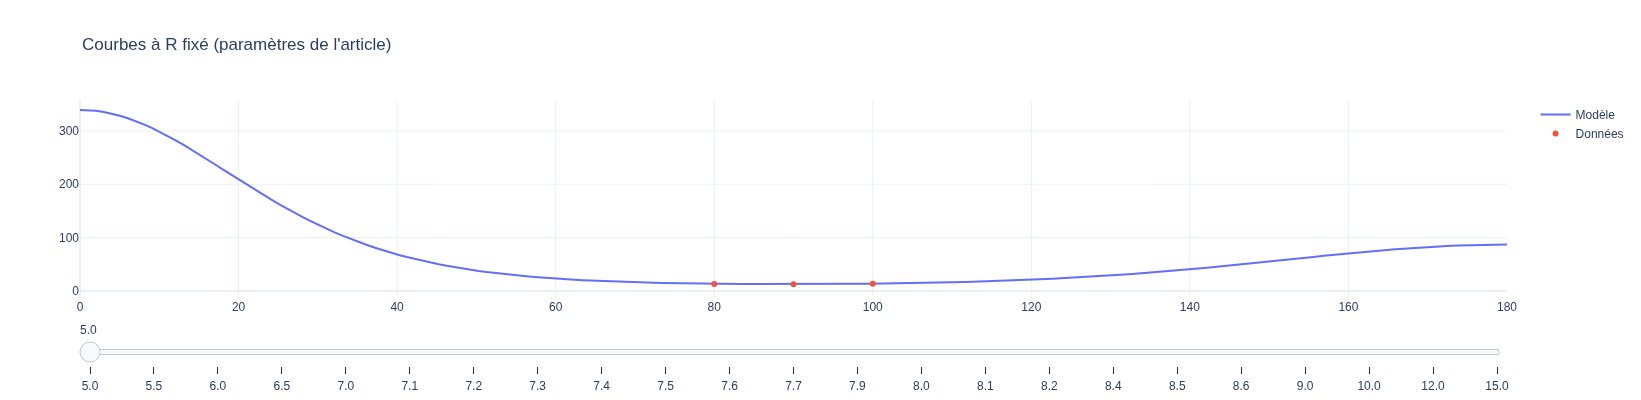

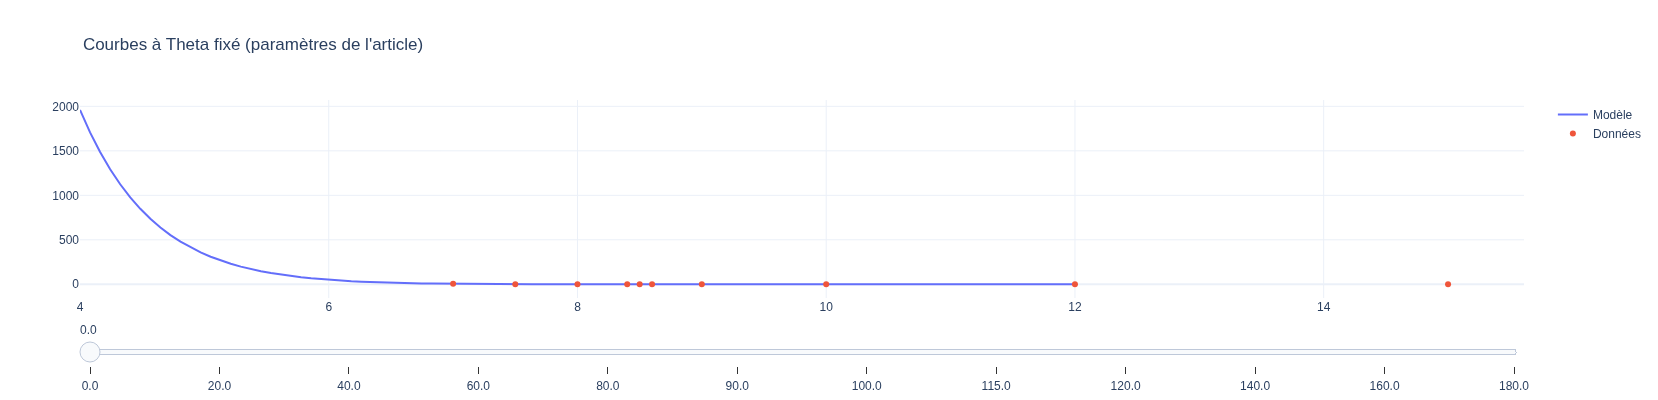

In [15]:
R_vals = np.array([5.0,5.5,6.0,6.5,7.0,7.1,7.2,7.3,7.4,7.5,7.6,7.7,
                   7.9,8.0,8.1,8.2,8.4,8.5,8.6,9.0,10.0,12.0,15.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_Ar, R_vals, x, Ar,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé (paramètres de l'article)")
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_Ar, Theta_vals, x_R, Ar,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé (paramètres de l'article)",fixed_first=False)

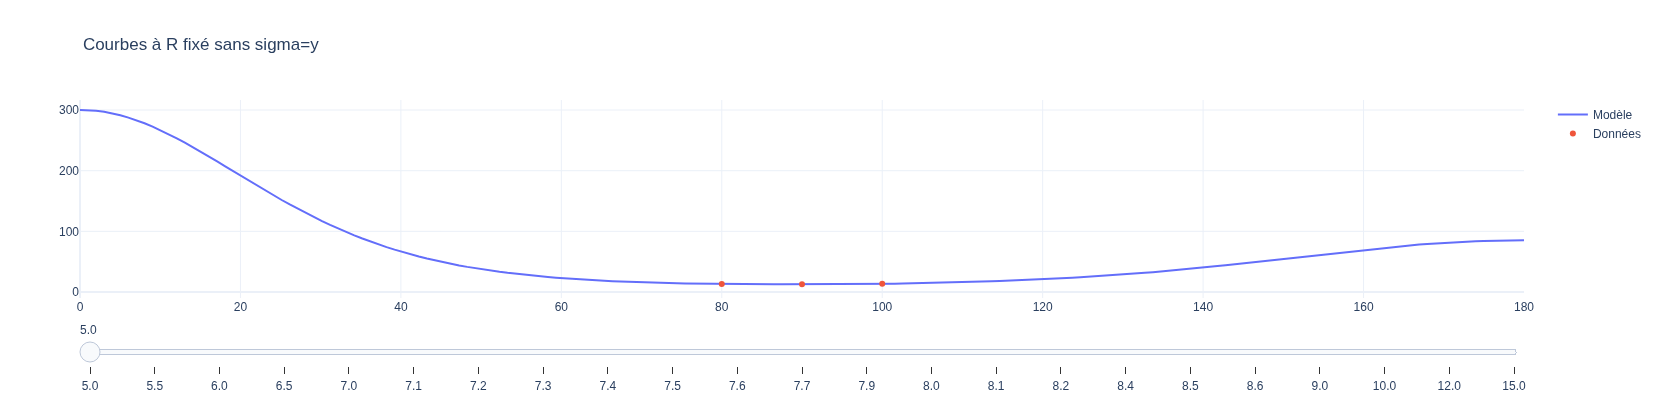

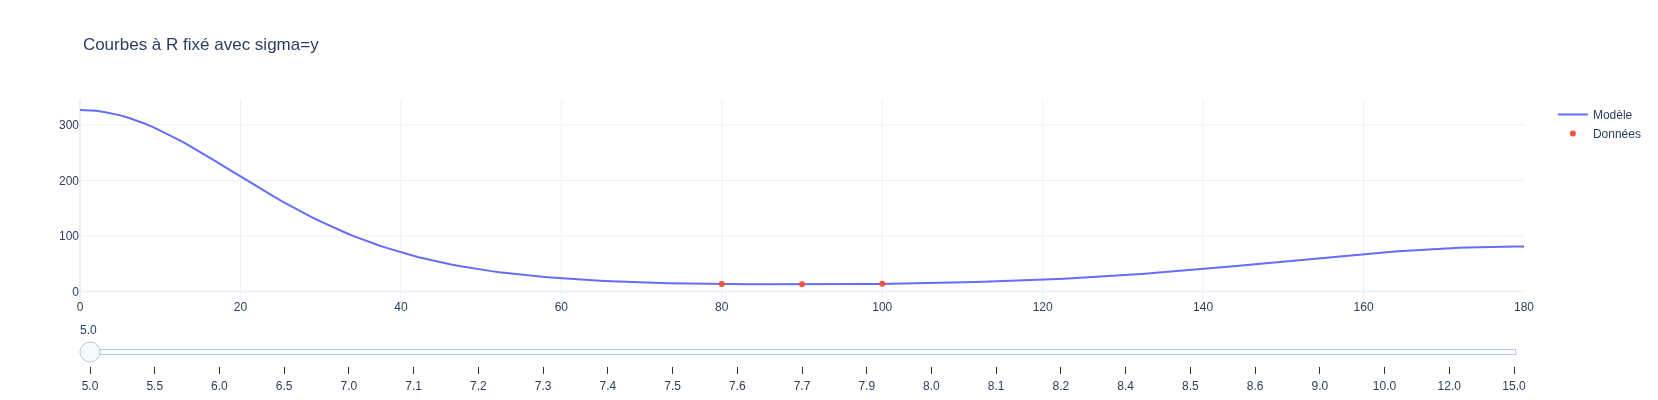

In [16]:
R_vals = np.array([5.0,5.5,6.0,6.5,7.0,7.1,7.2,7.3,7.4,7.5,7.6,7.7,
                   7.9,8.0,8.1,8.2,8.4,8.5,8.6,9.0,10.0,12.0,15.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_cf, R_vals, x, Ar,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans sigma=y")
plot_interactif(V_opt, params_opt_cf_sigma, R_vals, x, Ar,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec sigma=y")

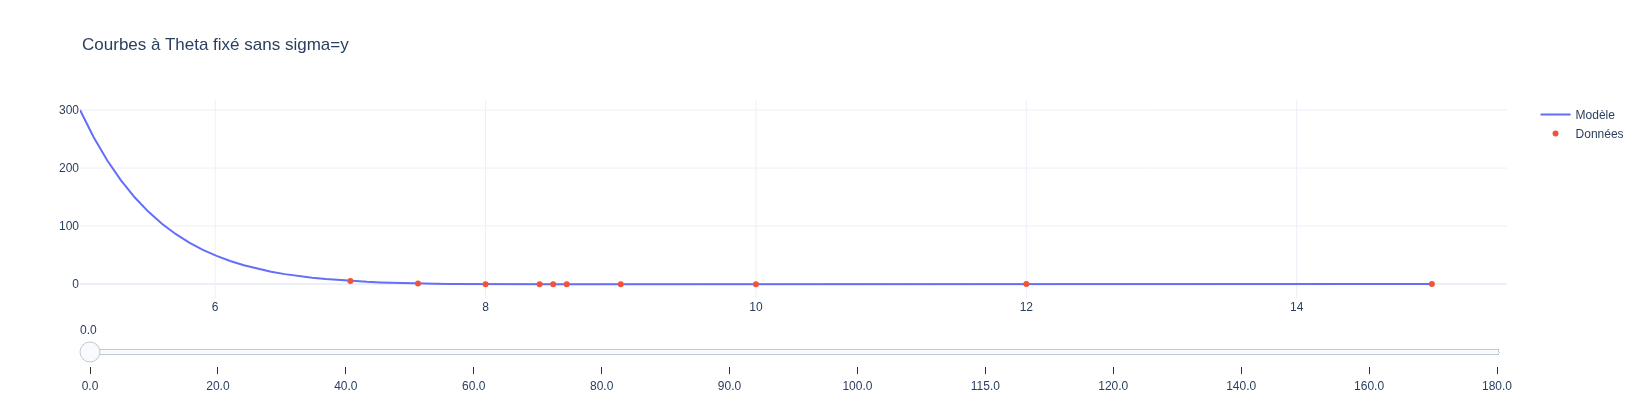

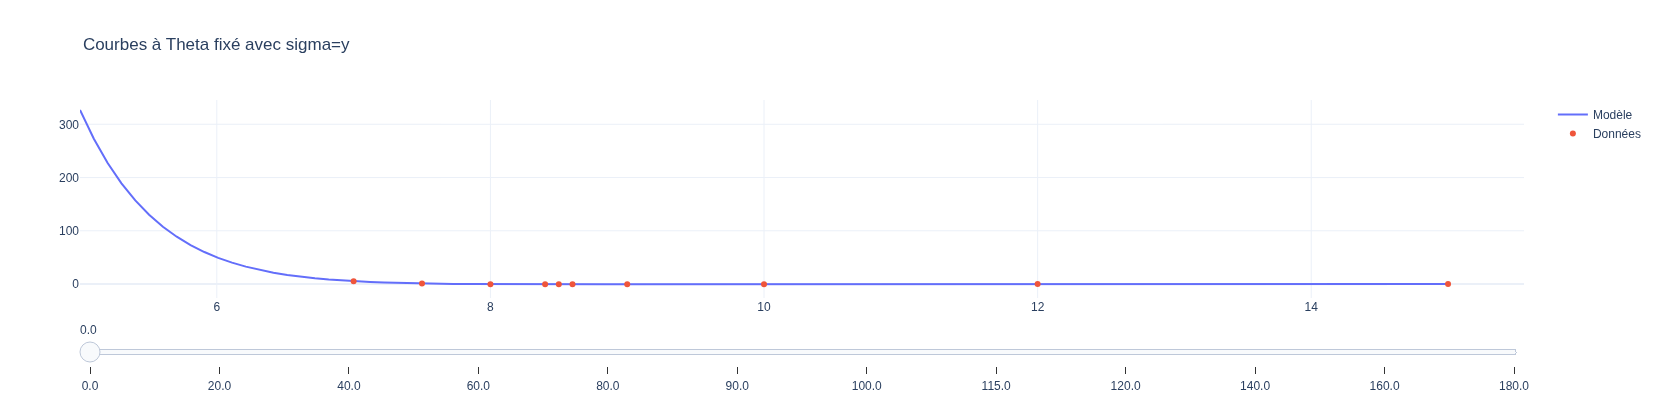

In [17]:
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(5, 15, 100)
plot_interactif(V_opt, params_opt_cf, Theta_vals, x_R, Ar,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé sans sigma=y",fixed_first=False)
plot_interactif(V_opt, params_opt_cf_sigma, Theta_vals, x_R, Ar,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé avec sigma=y",fixed_first=False)

## Contour plot

In [37]:
def contour_plot(ax, params, title):
    # Axes
    theta_grid = np.linspace(0, 180, 250)
    r_grid = np.linspace(6, 10, 250)
    
    Theta_mesh, R_mesh = np.meshgrid(theta_grid, r_grid)
    
    # Calcul de Z
    Z = np.array([V_opt(params, np.full_like(theta_grid, r), theta_grid) for r in r_grid])
    
    # Niveaux
    levels_to_plot = np.array([
        -0.149, -0.189,
        -0.229, -0.269, -0.309, -0.349, -0.389, -0.429,
        -0.469, -0.489, -0.509, -0.549, -0.568, -0.588, 
        -0.629, -0.661
    ])
    
    levels_with_labels = np.array([
        -0.229, -0.309, -0.389, -0.469, -0.509,
        -0.549, -0.568, -0.629, -0.661
    ])
    
    # niveaux intermédiaires
    levels_fine = []
    for i in range(len(levels_to_plot) - 1):
        a, b = levels_to_plot[i], levels_to_plot[i + 1]
        inter = np.linspace(a, b, 6)
        levels_fine.extend(inter[1:-1])
    
    levels_fine = np.sort(np.unique(levels_fine))
    
    # Contours gris
    ax.contour(
        Theta_mesh, R_mesh, Z,
        levels=levels_fine,
        colors='gray',
        linewidths=0.7
    )
    
    # Contours principaux
    all_contours = []
    for level in levels_to_plot:
        cp = ax.contour(
            Theta_mesh, R_mesh, Z,
            levels=[level],
            colors='black',
            linewidths=1.5,
            linestyles='--'
        )
        all_contours.append(cp)
    
    # Labels
    for cp in all_contours:
        level = cp.levels[0]
        if np.isclose(levels_with_labels, level).any():
            ax.clabel(cp, fmt='%.3f', fontsize=10, inline=True)
    
    ax.set_title(f"Ar-HCN - Energie potentielle (mEh)\n{title}")
    ax.set_xlabel("Theta (°)")
    ax.set_ylabel("R")
    
    ax.set_yticks(np.arange(6, 10.5, 0.5))
    ax.set_xticks(np.arange(0, 181, 30))
    
    ax.grid(True, linestyle='--', alpha=0.3)

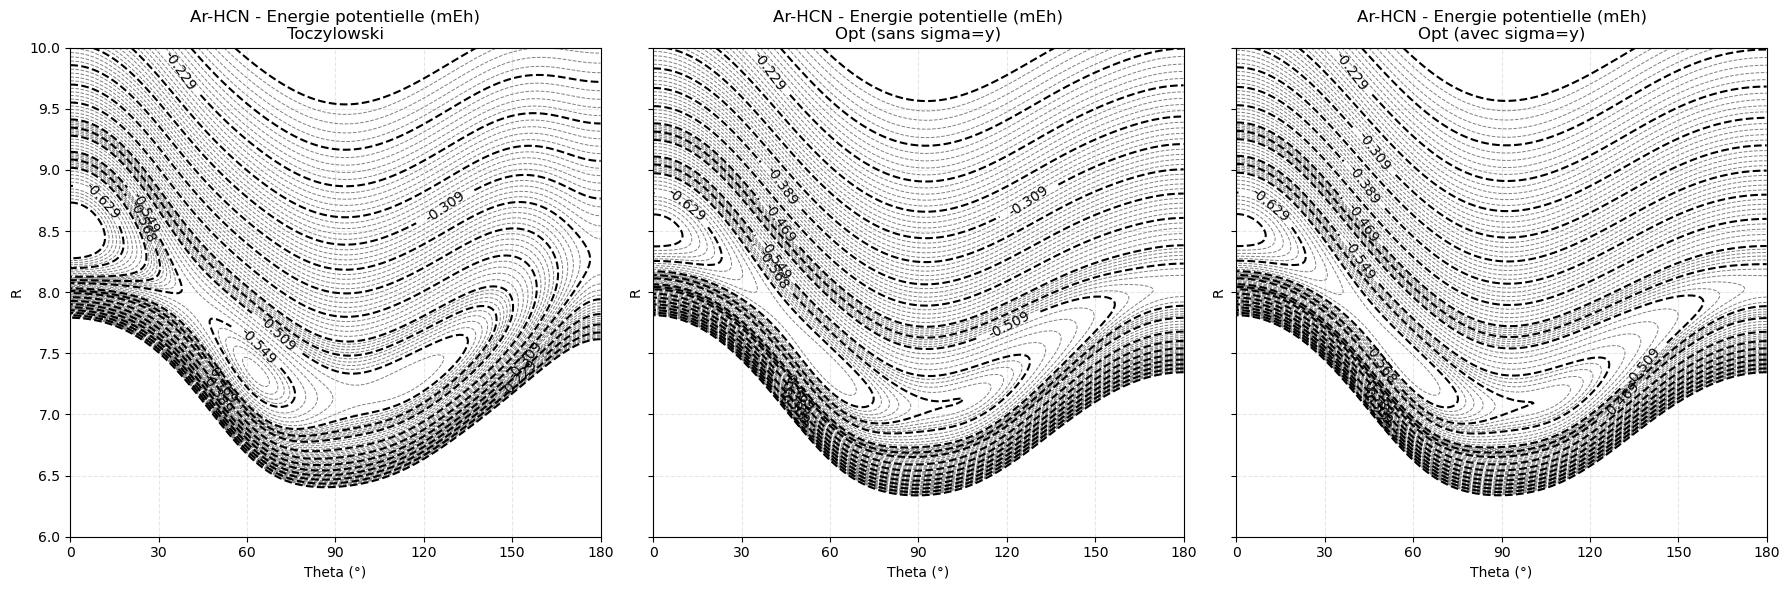

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

contour_plot(axes[0], params_Ar, "Toczylowski")
contour_plot(axes[1], params_opt_cf, "Opt (sans sigma=y)")
contour_plot(axes[2], params_opt_cf_sigma, "Opt (avec sigma=y)")

plt.tight_layout()